# **Target E-Commerce Sales Analysis**


### Overview

The e-commerce landscape in Brazil is rapidly evolving, driven by diverse consumer preferences and regional market dynamics. This project analyzes a comprehensive dataset from Target, containing over 1.4 million records across 7 distinct tables such as customers, orders, products, payments, and geolocation. By connecting to a MySQL database and efficiently managing large CSV files with 100k+ rows, I utilized Python and SQL to streamline data ingestion and ensure data integrity.

Using data-driven approaches, I explored key business questions that addresses critical operational and strategic insights to help drive informed decisions. These include identifying all unique customer cities, counting orders placed in 2017, and calculating total sales per product category. I also explored payment trends through installment percentages, mapped customer distribution by state, and tracked monthly order volumes in 2018. Further, I analyzed purchasing patterns by city, revenue contributions by category, correlations between price and purchase frequency, and ranked sellers by revenue.

To capture customer behavior over time, I calculated moving averages of order values, monthly cumulative sales, year-over-year growth, retention rates within six months of first purchase, and identified top-spending customers annually. This comprehensive analysis combines data engineering with business insights to reveal patterns that optimize sales, enhance customer retention, and support sustainable growth in the competitive e-commerce landscape. This analysis not only uncovers critical insights for business decision-making but also demonstrates the power of integrating large-scale datasets with analytical tools to drive operational efficiency and strategic growth in e-commerce.


### Objectives

- List all unique cities where customers are located

- Count the number of orders placed in 2017

- Find total sales per category

- Calculate the percentage of orders paid in installments

- Count the number of customers from each state

- Calculate the number of orders per month in 2018

- Find average number of products per order by customer city

- Calculate percentage of total revenue by product category

- Identify correlation between product price and purchase frequency

- Calculate total revenue by seller and rank sellers

- Calculate moving average of order values per customer over time

- Calculate cumulative sales per month per year

- Calculate year-over-year sales growth

- Calculate customer retention rate within 6 months of first purchase

- Identify top 3 customers by spending each year

### Importing the Dataset and Libraries


In [1]:
!pip install -qqq kagglehub
import kagglehub

path = kagglehub.dataset_download("devarajv88/target-dataset")

In [2]:
!pip install -qqq mysql-connector-python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

Imported the libaraies and conntected to the MySQL database. Created the tables and inserted the data from the CSV files. Since the data is very large, it took a lot of time to insert the data into the database.

I used this Python script from the GitHub repository to upload multiple CSV files (including large datasets with 100k+ rows) to a MySQL database efficiently. The script automatically drops and recreates the target database each time it runs, ensuring no duplicate data accumulates from repeated executions. It processes data in batches to handle large files without memory issues and includes robust error handling with automatic retry logic for connection problems. Before running, make sure to set your `folder_path` variable to point to your CSV files directory and update the database credentials in `DB_CONFIG` as needed.

In [ ]:
import pandas as pd
import mysql.connector
from mysql.connector import Error
import os
import time

DB_CONFIG = {
    'host': 'localhost',
    'user': 'XXX', # Enter your MySQL username here
    'password': 'XXX', # Enter your MySQL password here
    'database': 'target'
}

# List of CSV files and their corresponding table names
csv_files = [
    ('customers.csv', 'customers'),
    ('orders.csv', 'orders'),
    ('sellers.csv', 'sellers'),
    ('products.csv', 'products'),
    ('order_items.csv', 'order_items'),
    ('payments.csv', 'payments'),
    ('geolocation.csv', 'geolocation')
]

# Folder containing the CSV files 
folder_path = r"###"  # Add your folder path here

# Configuration for batch processing
BATCH_SIZE = 1000  # Process data in batches to avoid memory/connection issues
MAX_RETRIES = 3    # Number of retries for failed operations

def get_sql_type(dtype, series=None):
    """Convert pandas dtype to appropriate MySQL data type"""
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'DOUBLE' 
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:

        if series is not None:
            max_length = series.astype(str).str.len().max()
            if pd.isna(max_length) or max_length == 0:
                return 'VARCHAR(255)'
            elif max_length <= 255:
                return f'VARCHAR({min(255, max(50, int(max_length * 1.2)))})'
            else:
                return 'TEXT'
        return 'VARCHAR(255)'

def create_connection_with_retry():
    """Create database connection with retry logic"""
    for attempt in range(MAX_RETRIES):
        try:
            # Try with SSL disabled first
            config = DB_CONFIG.copy()
            config['ssl_disabled'] = True
            conn = mysql.connector.connect(**config)
            
            # Test the connection
            cursor = conn.cursor()
            cursor.execute("SELECT 1")
            cursor.fetchone()
            cursor.close()
            print(f"Successfully connected to MySQL database (SSL disabled)")
            return conn
            
        except (Error, AttributeError) as e:
            print(f"Connection attempt {attempt + 1} with SSL disabled failed: {e}")
            
            # Try without SSL parameters if SSL-related error
            try:
                conn = mysql.connector.connect(**DB_CONFIG)
                cursor = conn.cursor()
                cursor.execute("SELECT 1")
                cursor.fetchone()
                cursor.close()
                print(f"Successfully connected to MySQL database (default SSL)")
                return conn
            except Error as e2:
                print(f"Connection attempt {attempt + 1} with default SSL failed: {e2}")
                
            if attempt < MAX_RETRIES - 1:
                print(f"Retrying in 5 seconds...")
                time.sleep(5)
            else:
                raise Exception(f"Failed to connect after {MAX_RETRIES} attempts")

def recreate_database():
    """Drop and recreate the target database"""
    init_config = DB_CONFIG.copy()
    del init_config['database']
    
    for attempt in range(MAX_RETRIES):
        try:
            # Try with SSL disabled first
            config_with_ssl_disabled = init_config.copy()
            config_with_ssl_disabled['ssl_disabled'] = True
            
            try:
                conn = mysql.connector.connect(**config_with_ssl_disabled)
            except (Error, AttributeError):
                # If SSL disabled doesn't work, try default connection
                conn = mysql.connector.connect(**init_config)
            
            cursor = conn.cursor()
            
            # Drop database if exists and create new one
            cursor.execute(f"DROP DATABASE IF EXISTS `{DB_CONFIG['database']}`")
            cursor.execute(f"CREATE DATABASE `{DB_CONFIG['database']}`")
            
            print(f"Database '{DB_CONFIG['database']}' has been recreated successfully")
            
            cursor.close()
            conn.close()
            return
            
        except Error as e:
            print(f"Database recreation attempt {attempt + 1} failed: {e}")
            if attempt < MAX_RETRIES - 1:
                print("Retrying in 5 seconds...")
                time.sleep(5)
            else:
                raise

def upload_csv_to_table(csv_file, table_name, folder_path):
    """Upload a single CSV file to a MySQL table with batch processing"""
    file_path = os.path.join(folder_path, csv_file)
    
    # Check if file exists
    if not os.path.exists(file_path):
        print(f"Warning: File {file_path} not found. Skipping...")
        return
    
    print(f"Processing {csv_file}...")
    
    try:
        # Read the CSV file into a pandas DataFrame
        df = pd.read_csv(file_path)
        
        if df.empty:
            print(f"Warning: {csv_file} is empty. Skipping...")
            return
        
        print(f"Loaded {len(df)} rows from {csv_file}")
        
        # Replace NaN with None to handle SQL NULL
        df = df.where(pd.notnull(df), None)
        
        # Clean column names
        df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]
        
        # Create connection for this table
        conn = create_connection_with_retry()
        cursor = conn.cursor()
        
        try:
            # Generate the CREATE TABLE statement
            columns = []
            for col in df.columns:
                sql_type = get_sql_type(df[col].dtype, df[col])
                columns.append(f'`{col}` {sql_type}')
            
            create_table_query = f'CREATE TABLE `{table_name}` ({", ".join(columns)})'
            cursor.execute(create_table_query)
            print(f"Created table '{table_name}'")
            
            # Prepare batch insert
            if not df.empty:
                placeholders = ', '.join(['%s'] * len(df.columns))
                columns_str = ', '.join([f'`{col}`' for col in df.columns])
                insert_query = f"INSERT INTO `{table_name}` ({columns_str}) VALUES ({placeholders})"
                
                # Process data in batches
                total_rows = len(df)
                rows_inserted = 0
                
                for start_idx in range(0, total_rows, BATCH_SIZE):
                    end_idx = min(start_idx + BATCH_SIZE, total_rows)
                    batch_df = df.iloc[start_idx:end_idx]
                    
                    # Convert batch to list of tuples
                    batch_data = []
                    for _, row in batch_df.iterrows():
                        values = tuple(None if pd.isna(x) else x for x in row)
                        batch_data.append(values)
                    
                    # Insert batch with retry logic
                    batch_inserted = False
                    for attempt in range(MAX_RETRIES):
                        try:
                            cursor.executemany(insert_query, batch_data)
                            conn.commit()
                            rows_inserted += len(batch_data)
                            batch_inserted = True
                            print(f"Inserted batch {start_idx//BATCH_SIZE + 1}: {rows_inserted}/{total_rows} rows")
                            break
                        except Error as e:
                            print(f"Batch insert attempt {attempt + 1} failed: {e}")
                            if attempt < MAX_RETRIES - 1:
                                cursor.close()
                                conn.close()
                                conn = create_connection_with_retry()
                                cursor = conn.cursor()
                                time.sleep(2)
                            else:
                                raise
                    
                    if not batch_inserted:
                        raise Exception(f"Failed to insert batch after {MAX_RETRIES} attempts")
                
                print(f"Successfully inserted all {rows_inserted} rows into '{table_name}'")
        
        finally:
            cursor.close()
            conn.close()
            
    except Exception as e:
        print(f"Error processing {csv_file}: {e}")
        raise

def main():
    """Main function to orchestrate the data upload process"""
    print("Starting data upload process...")
    
    # Validate folder path
    if not folder_path or not os.path.exists(folder_path):
        print(f"Error: Please set a valid folder_path. Current path: '{folder_path}'")
        return
    
    try:
        # Recreate the database
        print("Step 1: Recreating database...")
        recreate_database()
        
        # Wait a bit for database to be fully ready
        time.sleep(2)
        
        # Process each CSV file
        print("Step 2: Processing CSV files...")
        for csv_file, table_name in csv_files:
            try:
                upload_csv_to_table(csv_file, table_name, folder_path)
                print(f"Completed processing {table_name}")
                # Small delay between tables
                time.sleep(1)
            except Exception as e:
                print(f"Failed to process {csv_file}: {e}")
                # Continue with next file instead of stopping entirely
                continue
        
        print("\nData upload process completed!")
        
        # Display summary
        print("\n--- Database Summary ---")
        conn = create_connection_with_retry()
        cursor = conn.cursor()
        
        try:
            for _, table_name in csv_files:
                try:
                    cursor.execute(f"SELECT COUNT(*) FROM `{table_name}`")
                    count = cursor.fetchone()[0]
                    print(f"Table '{table_name}': {count:,} rows")
                except Error:
                    print(f"Table '{table_name}': Not found or error occurred")
        finally:
            cursor.close()
            conn.close()
        
    except Exception as e:
        print(f"Error during upload process: {e}")
        raise

if __name__ == "__main__":
    main()

Starting data upload process...
Step 1: Recreating database...
Database 'target' has been recreated successfully
Step 2: Processing CSV files...
Processing customers.csv...
Loaded 99441 rows from customers.csv
Successfully connected to MySQL database (SSL disabled)
Created table 'customers'
Inserted batch 1: 1000/99441 rows
Inserted batch 2: 2000/99441 rows
Inserted batch 3: 3000/99441 rows
Inserted batch 4: 4000/99441 rows
Inserted batch 5: 5000/99441 rows
Inserted batch 6: 6000/99441 rows
Inserted batch 7: 7000/99441 rows
Inserted batch 8: 8000/99441 rows
Inserted batch 9: 9000/99441 rows
Inserted batch 10: 10000/99441 rows
Inserted batch 11: 11000/99441 rows
Inserted batch 12: 12000/99441 rows
Inserted batch 13: 13000/99441 rows
Inserted batch 14: 14000/99441 rows
Inserted batch 15: 15000/99441 rows
Inserted batch 16: 16000/99441 rows
Inserted batch 17: 17000/99441 rows
Inserted batch 18: 18000/99441 rows
Inserted batch 19: 19000/99441 rows
Inserted batch 20: 20000/99441 rows
Insert

Connecting to the MySQL database and creating a connection object

In [10]:
db = mysql.connector.connect(
    host="localhost",
    user="root",
    password="parshvpatel@0910",
    database="target")

cursor = db.cursor()

---
### Listing all unique cities where customers are located

In [11]:
query = "SELECT DISTINCT(customer_city) FROM customers"
cursor.execute(query)

results = cursor.fetchall()

print("There are", len(results), "unique cities in the customers table.")
print("The first 5 rows are:")
for row in results[:5]:
    print(row[0].capitalize())

There are 4119 unique cities in the customers table.
The first 5 rows are:
Franca
Sao bernardo do campo
Sao paulo
Mogi das cruzes
Campinas


---

### Counting the number of orders placed in 2017

In [12]:
query = "SELECT COUNT(*) FROM orders WHERE order_purchase_timestamp LIKE '2017%'"
cursor.execute(query)
results = cursor.fetchall()
print("There are total", results[0][0], "orders in 2017.")


There are total 45101 orders in 2017.


---
### Finding total sales per category

In [13]:
query = """SELECT products.product_category, SUM(payments.payment_value) 
FROM products 
JOIN order_items ON products.product_id = order_items.product_id 
JOIN payments ON order_items.order_id = payments.order_id 
GROUP BY products.product_category"""

cursor.execute(query)
result = cursor.fetchall()
for row in result[0:5]:
    print(row)

('telephony', 486882.05000000884)
('Market Place', 45335.919999999955)
('Fashion Bags and Accessories', 218158.28000000006)
('automotive', 852294.3300000003)
('bed table bath', 1712553.6699999967)


Since the values have a lot of decimal places, I rounded them to 2 decimal places and also lowered the product category to make it easier to read.

In [14]:
query = """SELECT lower(products.product_category), round(SUM(payments.payment_value), 2) 
FROM products 
JOIN order_items ON products.product_id = order_items.product_id 
JOIN payments ON order_items.order_id = payments.order_id 
GROUP BY products.product_category"""

cursor.execute(query)
result = cursor.fetchall()
for row in result[0:5]:
    row = list(row)
    print(row[0], "\t:", row[1])

telephony 	: 486882.05
market place 	: 45335.92
fashion bags and accessories 	: 218158.28
automotive 	: 852294.33
bed table bath 	: 1712553.67


Creating a dataframe from this values. Then, I sorted the values in descending order and reset the index. Finally, I displayed the first 5 rows of the dataframe.

In [15]:
df = pd.DataFrame(result, columns=["Product Category", "Total Payment"])
df.sort_values(by="Total Payment", ascending=False, inplace=True)
df.reset_index(drop=True, inplace=True)
df.head()

,Product Category,Total Payment
0,bed table bath,1712553.67
1,health beauty,1657373.12
2,computer accessories,1585330.45
3,furniture decoration,1430176.39
4,watches present,1429216.68


Now, I can create a bar chart to visualize the total payment for first 10 high payment product category.

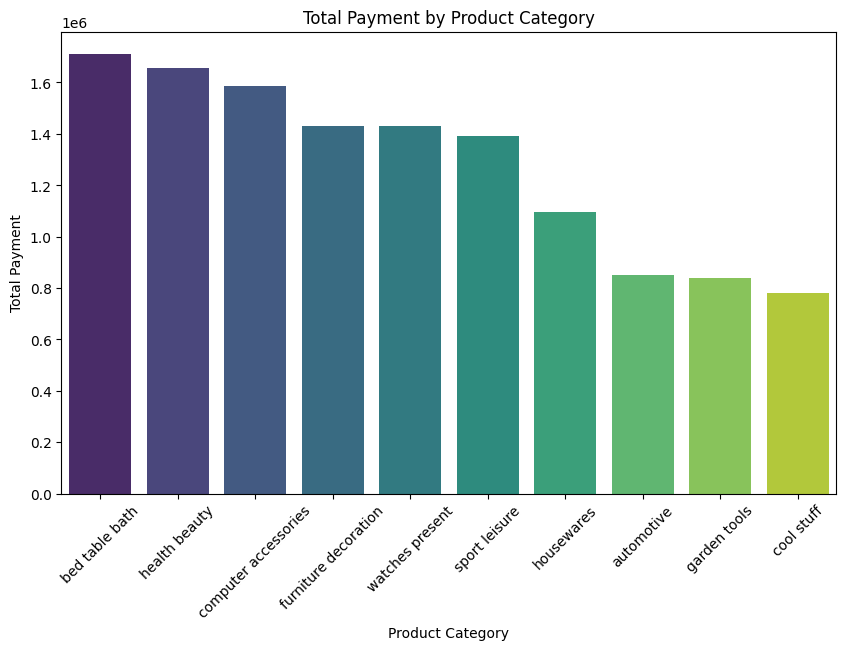

In [16]:
import warnings
warnings.filterwarnings("ignore")

plt.figure(figsize=(10, 6))
sns.barplot(data=df.head(10), x='Product Category', y='Total Payment', palette='viridis')
plt.title('Total Payment by Product Category')
plt.xlabel('Product Category')
plt.xticks(rotation=45)
plt.ylabel('Total Payment')
plt.show()

As we can see from the bar chart, `bed table bath` has the highest total payment of 1712553.67, followed by `health beauty` and `computer accessories`



----

### Calculating the percentage of orders that were paid in installments

Getting the sum of orders paid in installments where installments >= 1 and calculating the percentage of total orders

In [17]:
query = """SELECT sum(case when payments.payment_installments >= 1 then 1 
else 0 end) / count(*) * 100 as percentage FROM payments"""

cursor.execute(query)
result = cursor.fetchone()
print("Percentage of orders paid in installments:", result[0])

Percentage of orders paid in installments: 99.9981


The percentage of orders paid in installments is very high which is 99.998% of the customers who have made payments in atleast 1 installments.

Also, calculating the number of orders where payment_installments is greater than 1 to get installment which have been paid more than once.

In [18]:
query = """SELECT sum(case when payments.payment_installments > 1 then 1 
else 0 end) / count(*) * 100 as percentage FROM payments"""

cursor.execute(query)
result = cursor.fetchone()
print("Percentage of orders paid in installments:", result[0])

Percentage of orders paid in installments: 49.4176


The percentage of orders paid in installments more than once drops significantly to 49.42%

----
### Counting the number of customers from each state

In [19]:
query = """SELECT customer_state, count(*) FROM customers group by customer_state"""

cursor.execute(query)
result = cursor.fetchall()

df_customers_state = pd.DataFrame(result, columns=["customer_state", "count"])
df_customers_state.head()

,customer_state,count
0,SP,41746
1,SC,3637
2,MG,11635
3,PR,5045
4,RJ,12852


In [20]:
df_customers_state.shape

(27, 2)

There are 27 states from the customers table

Sorting the df_customers_state by count in descending order to see the top 5 states with the most customers

In [21]:
df_customers_state.sort_values(by='count', ascending=False, inplace=True)
df_customers_state.reset_index(drop=True, inplace=True)
df_customers_state.head()

,customer_state,count
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045


Creating a bar chart to visualize the top 10 states with the most customers

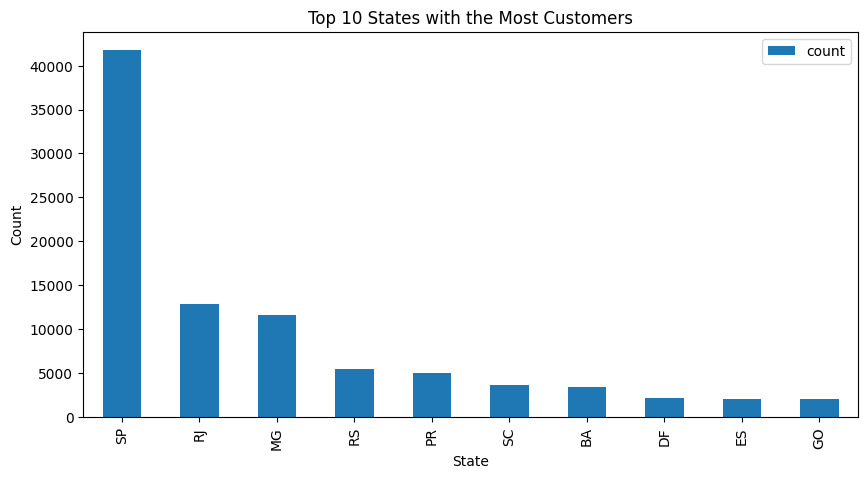

In [22]:
df_customers_state.head(10).plot(kind='bar', x='customer_state', y='count', figsize=(10, 5))
plt.title('Top 10 States with the Most Customers')
plt.xlabel('State')
plt.ylabel('Count')
plt.show()


As we can see, `SP` (São Paulo) state has significantly more customers than the other states. This is because it is the most populous state in Brazil and also has the highest number of cities. Sao Paulo is followed by `RJ` (Rio de Janeiro) and `MG` (Minas Gerais).

Creating a pie chart to show the distribution of customers by state for the top 5 states

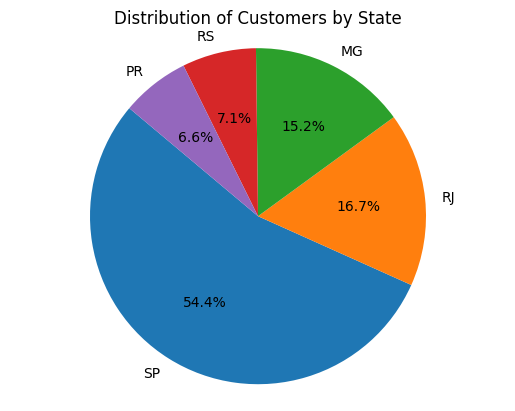

In [23]:
plt.pie(df_customers_state['count'].head(5), labels=df_customers_state['customer_state'].head(5), autopct='%1.1f%%', startangle=140)
plt.axis('equal')
plt.title('Distribution of Customers by State')
plt.show()

`SP` consists of the 54.4% of the total customers from the top 5 states followed by `RJ` with 16.7% and `RS` with 15.2%.

---
### Calculating the number of orders per month in 2018

Getting the Month names and count of orders from each month for the year 2018.

In [24]:
query = """SELECT monthname(order_purchase_timestamp) as month, count(order_id) as count 
FROM orders 
WHERE year(order_purchase_timestamp) = 2018
GROUP BY month"""

cursor.execute(query)
result = cursor.fetchall()
print(result)

[('July', 6292), ('August', 6512), ('February', 6728), ('June', 6167), ('March', 7211), ('January', 7269), ('May', 6873), ('April', 6939), ('September', 16), ('October', 4)]


Converting the result into a pandas dataframe

In [25]:
df_month = pd.DataFrame(result, columns=["Month", "Count"])
df_month.head()

,Month,Count
0,July,6292
1,August,6512
2,February,6728
3,June,6167
4,March,7211


Creating a bar chart to show the number of orders per month. I also sorted the months by count and rotated the x-axis labels to make them more readable.

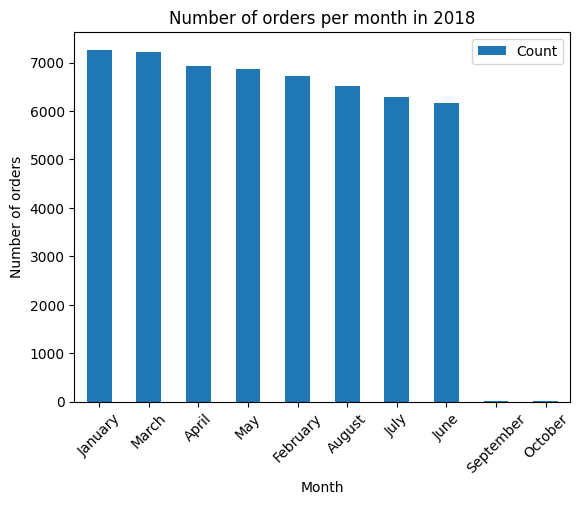

In [26]:
df_month.sort_values(by="Count", ascending=False).plot(kind="bar", x="Month", y="Count")
plt.xticks(rotation=45)
plt.title("Number of orders per month in 2018")
plt.xlabel("Month")
plt.ylabel("Number of orders")
plt.show();

In [27]:
df_month.sort_values(by="Count", ascending=True).head(2)

,Month,Count
9,October,4
8,September,16


`January` and  `March` has the highest number of orders. There is something unsual for the `September` and `October` months as they only have 16 and 4 orders respectively, which is very low compared to other months. Maybe the data was collected for these months.

I dedicided to recreate the plot and removing the `September` and `October` months.

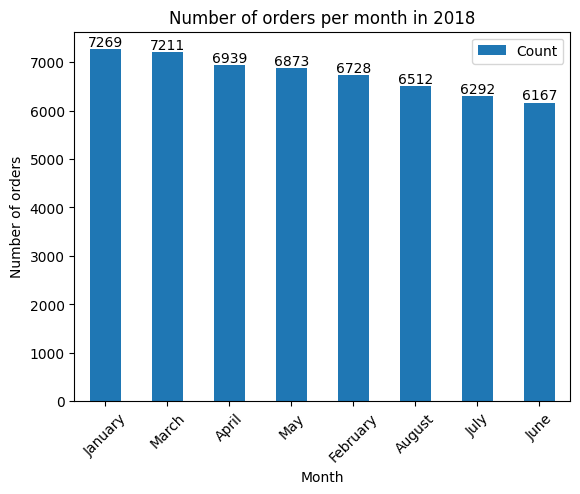

In [28]:
ax= df_month.sort_values(by="Count", ascending=False).head(8).plot(kind="bar", x="Month", y="Count")
ax.set_title("Number of orders per month in 2018")
ax.set_xlabel("Month")
ax.set_ylabel("Number of orders")
ax.set_xticklabels(df_month.sort_values(by="Count", ascending=False).head(8)["Month"], rotation=45)
ax.bar_label(ax.containers[0])
plt.show();

I also created a pie chart to show the percentage of orders per month.

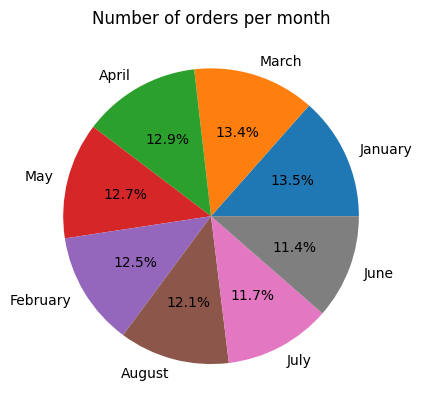

In [29]:
plt.pie(df_month.sort_values(by="Count", ascending=False)["Count"].head(8), labels=df_month.sort_values(by="Count", ascending=False).head(8)["Month"], autopct="%1.1f%%")
plt.title("Number of orders per month")
plt.show();

`January` consist of 13.5 % of the total orders and `March` consist of 13.4% of the total orders in 2018. `June` and `July` consist of the least amount of orders with 11.4% and 11.7% of the total orders.

I also created a line chart to show the trend of orders over time.

In [30]:
query = """SELECT month(order_purchase_timestamp) as month, count(order_id) as count 
FROM orders 
WHERE year(order_purchase_timestamp) = 2018
GROUP BY month"""

cursor.execute(query)
result = cursor.fetchall()

df = pd.DataFrame(result, columns=["month", "count"])
df.head()

,month,count
0,7,6292
1,8,6512
2,2,6728
3,6,6167
4,3,7211


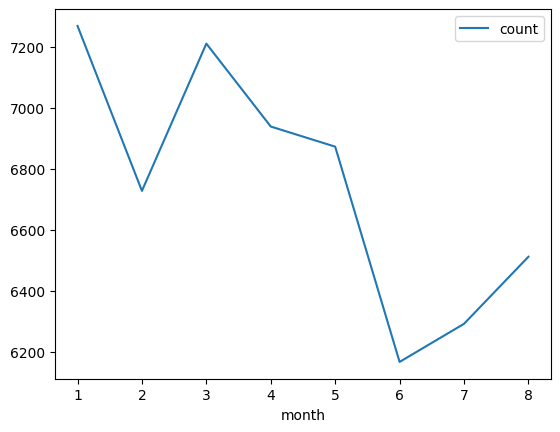

In [31]:
df.sort_values(by="month").head(8).plot(kind="line", x="month", y="count")
plt.show()

As we can see, the sales drops significantly from May to June and then starts to increase again for the year 2018.

--- 
### Finding the average number of products per order grouped by customer city

Created a temporary table count_per_order to count the number of items per order from the orders and order_items tables. Then, I joined the count_per_order table with the customers table to get the customer city and the average number of items per order grouped by customer city. Then, I rounded the average number of items to 2 decimal places and printed the first 5 rows of the result.

In [32]:
query = """with count_per_order as (SELECT orders.order_id, orders.customer_id, count(order_items.order_id) as total_items 
FROM orders JOIN order_items ON orders.order_id = order_items.order_id
group by orders.order_id, orders.customer_id)

select customers.customer_city, round(avg(count_per_order.total_items), 2) as avg_items 
from count_per_order 
join customers on count_per_order.customer_id = customers.customer_id
GROUP BY customers.customer_city"""

cursor.execute(query)
result = cursor.fetchall()
for row in result[:5]:
    print(row[0].capitalize(), "\t:", row[1])

Franca 	: 1.25
Sao bernardo do campo 	: 1.14
Sao paulo 	: 1.16
Mogi das cruzes 	: 1.16
Campinas 	: 1.16


Converting the results into a pandas dataframe

In [33]:
df_city_items = pd.DataFrame(result, columns=["Customer City", "Average Items per Order"])
df_city_items.head()

,Customer City,Average Items per Order
0,franca,1.25
1,sao bernardo do campo,1.14
2,sao paulo,1.16
3,mogi das cruzes,1.16
4,campinas,1.16


In [34]:
print("There are", df_city_items.shape[0], "cities in the dataset")

There are 4110 cities in the dataset


Sorting the df_city_items dataframe by the average items per order in descending order

In [35]:
df_city_items.sort_values(by="Average Items per Order", ascending=False, inplace=True)
df_city_items.reset_index(drop=True, inplace=True)
df_city_items.head()

,Customer City,Average Items per Order
0,padre carvalho,7.00
1,celso ramos,6.50
2,candido godoi,6.00
3,datas,6.00
4,matias olimpio,5.00


`Padre Carvalho` city has the highest average items per order with 7 items per order, followed by `Celso Ramos` and `Candido Godoi`.

---
### Calculating the percentage of total revenue contributed by each product category

I used a similar query to find the percentage of sales for each product category. First, I found the total sales for each product category and divide it by the total sales for all product categories to get the percentage of sales for each product category. Then, I sorted the results in descending order to get the product categories with the highest percentage of sales. Then, I displayed the top 5 product categories with the highest percentage of sales.

In [36]:
query = """
SELECT lower(products.product_category), round(SUM(payments.payment_value)/(select sum(payment_value) from payments)*100, 2) as percentage
FROM products 
JOIN order_items ON products.product_id = order_items.product_id 
JOIN payments ON order_items.order_id = payments.order_id 
GROUP BY products.product_category
Order by percentage desc

"""

cursor.execute(query)
results = cursor.fetchall()
for row in results[:5]:
    print(row[0], "\t: ", row[1], "%")

bed table bath 	:  10.7 %
health beauty 	:  10.35 %
computer accessories 	:  9.9 %
furniture decoration 	:  8.93 %
watches present 	:  8.93 %


Creating a dataframe to store the results

In [37]:
df_percentage = pd.DataFrame(results, columns=["product_category", "percentage"])
df_percentage.head()

,product_category,percentage
0,bed table bath,10.70
1,health beauty,10.35
2,computer accessories,9.90
3,furniture decoration,8.93
4,watches present,8.93


`Bed table bath` has the highest percentage of sales at 10.7%, followed by `health beauty` at 10.35%, and `computer accessories` at 9.90%.

Creating a pie chart to show the percentage of sales for the top 10 product categories

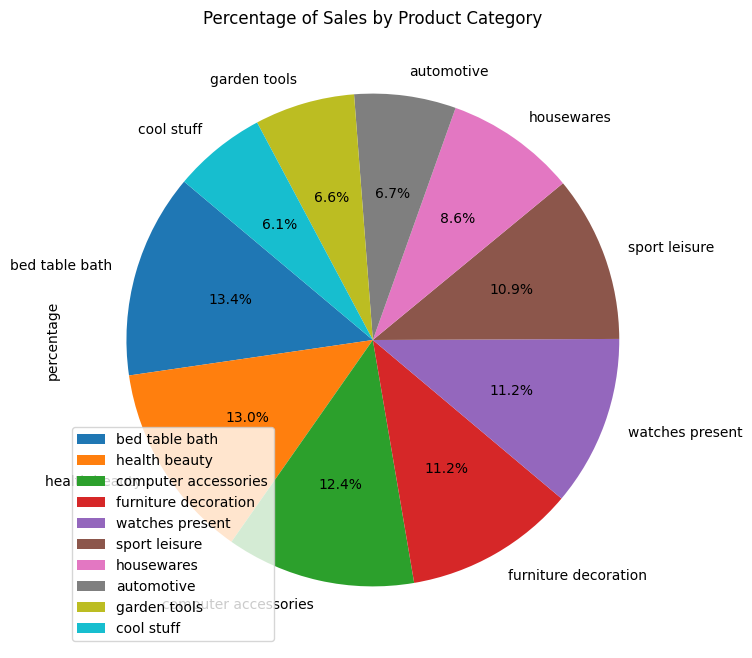

In [75]:
df_percentage[:10].plot(kind='pie', y='percentage', labels=df_percentage['product_category'], autopct='%1.1f%%', startangle=140, figsize=(8, 8))
plt.title('Percentage of Sales by Product Category')
plt.show()

---
### Identifying the correlation between product price and the number of times a product has been purchased

Selecting the number of total orders per product category and getting the average price of each product category because the price has been changing for each product category so I took the average price of each product category.

In [48]:
query= """SELECT products.product_category,
count(order_items.product_id) AS total_quantity,
ROUND(AVG(order_items.price), 2) AS average_price
FROM products join order_items 
on products.product_id = order_items.product_id
GROUP BY products.product_category"""

cursor.execute(query)
result = cursor.fetchall()
print("Product Category  Total Quantity  Average Price")
for row in result[:5]:
    print(row[0], "\t:", row[1], ",", row[2])

Product Category  Total Quantity  Average Price
sport leisure 	: 8641 , 114.34
Watches present 	: 5991 , 201.14
housewares 	: 6964 , 90.79
Cool Stuff 	: 3796 , 167.36
electronics 	: 2767 , 57.91


Creating a Dataframe from the result of the query

In [49]:
df_product_category = pd.DataFrame(result, columns=["Product Category", "Total Quantity", "Average Price"])
df_product_category.sort_values(by="Total Quantity", ascending=False)
df_product_category.head()

,Product Category,Total Quantity,Average Price
0,sport leisure,8641,114.34
1,Watches present,5991,201.14
2,housewares,6964,90.79
3,Cool Stuff,3796,167.36
4,electronics,2767,57.91


In [53]:
correlation = df_product_category["Total Quantity"].corr(df_product_category["Average Price"]).item(0)
print("Correlation between Total Quantity and Average Price: ", round(correlation, 2))


Correlation between Total Quantity and Average Price:  -0.11


There is a very weak negative correlation between the total quantity and average price of products in each category. This means that as the average price of products in a category increases, the total quantity of products in that category does not change much. This suggests that a product's price does not have a significant impact on the quantity of products sold in that category. 

---
### Calculating the total revenue generated by each seller

I selected the seller id and rounded the sum of the payment value to 2 decimal places and grouped the results by seller id and ordered the results by total revenue in descending order. I then printed the first 5 rows of the results.

In [58]:
query= """
SELECT order_items.seller_id,
round(SUM(payments.payment_value), 2) AS total_revenue
FROM order_items
JOIN payments ON order_items.order_id = payments.order_id
GROUP BY order_items.seller_id
ORDER BY total_revenue DESC
"""

cursor.execute(query)
total_revenue = cursor.fetchall()
for row in total_revenue[0:5]:
    print(row[0], row[1])

7c67e1448b00f6e969d365cea6b010ab 507166.91
1025f0e2d44d7041d6cf58b6550e0bfa 308222.04
4a3ca9315b744ce9f8e9374361493884 301245.27
1f50f920176fa81dab994f9023523100 290253.42
53243585a1d6dc2643021fd1853d8905 284903.08


I added ranks to the sellers based on their revenue by the dense_rank() function

In [71]:
query= """ select *, dense_rank() over(order by revenue DESC) as rn from
(select order_items.seller_id,
round(SUM(payments.payment_value), 2) as revenue
FROM order_items
JOIN payments ON order_items.order_id = payments.order_id
GROUP BY order_items.seller_id) as a
"""

cursor.execute(query)
total_revenue = cursor.fetchall()
for row in total_revenue[0:5]:
    print(row[0], row[1], row[2])

7c67e1448b00f6e969d365cea6b010ab 507166.91 1
1025f0e2d44d7041d6cf58b6550e0bfa 308222.04 2
4a3ca9315b744ce9f8e9374361493884 301245.27 3
1f50f920176fa81dab994f9023523100 290253.42 4
53243585a1d6dc2643021fd1853d8905 284903.08 5


I created a dataframe from the total revenue results query

In [72]:
df_sellers = pd.DataFrame(total_revenue, columns=["seller_id", "revenue", "rank"])
df_sellers.head()

,seller_id,revenue,rank
0,7c67e1448b00f6e969d365cea6b010ab,507166.91,1
1,1025f0e2d44d7041d6cf58b6550e0bfa,308222.04,2
2,4a3ca9315b744ce9f8e9374361493884,301245.27,3
3,1f50f920176fa81dab994f9023523100,290253.42,4
4,53243585a1d6dc2643021fd1853d8905,284903.08,5


`7c67e1448b00f6e969d365cea6b010ab` seller_id has the highest revenue of 507166.91 as the rank 1.

Creating a bar chart for the top 10 sellers by revenue and displaying only the first 5 letters of the seller_id

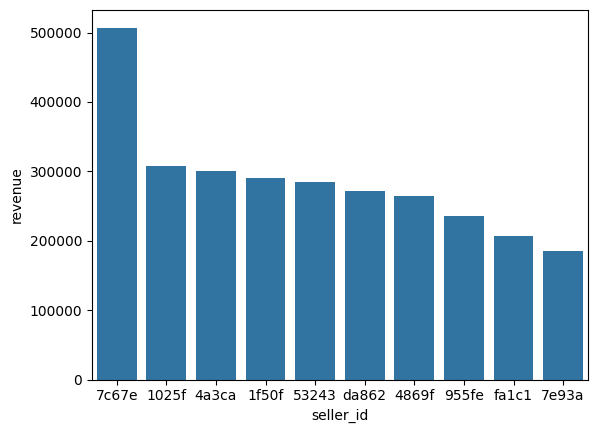

In [74]:
df_sellers_top10 = df_sellers.head(10)
df_sellers_top10['seller_id'] = df_sellers_top10['seller_id'].str[:5]
sns.barplot(x="seller_id", y="revenue", data=df_sellers_top10)
plt.show()

`7c67e` seller has a significantly higher revenue than the other sellers.

---
### Calculating the moving average of order values for each customer over their order history

I calculated the moving average of the payment for each customer_id and order_purchase_timestamp by calculating the avaerage of 2 previous payments and the current payment as moving average and rounded it to 2 decimal places. I have displayed the customer_id, order_purchase_timestamp, payment and moving average of payment

In [86]:
query= """select customer_id, order_purchase_timestamp, payment,
round(avg(payment) over (partition by customer_id 
order by order_purchase_timestamp 
rows between 2 preceding and current row),2) as moving_avg_payment from 

(select orders.customer_id, 
orders.order_purchase_timestamp,
payments.payment_value as payment
from payments join orders 
on payments.order_id = orders.order_id) as a"""

db = mysql.connector.connect(
    host="localhost",
    user="root",
    password="parshvpatel@0910",
    database="target"
)

cursor = db.cursor()
cursor.execute(query)
result = cursor.fetchall()
for row in result[:5]:
    print(row[0], row[1], row[2], row[3])


00012a2ce6f8dcda20d059ce98491703 2017-11-14 16:08:26 114.74 114.74
000161a058600d5901f007fab4c27140 2017-07-16 09:40:32 67.41 67.41
0001fd6190edaaf884bcaf3d49edf079 2017-02-28 11:06:43 195.42 195.42
0002414f95344307404f0ace7a26f1d5 2017-08-16 13:09:20 179.35 179.35
000379cdec625522490c315e70c7a9fb 2018-04-02 13:42:17 107.01 107.01


Many values can be similar if the customers places only 1 order so the moving average will be the same as the payment.

Converting the results into a pandas dataframe.

In [93]:
df_moving_avg_payment = pd.DataFrame(result, columns=["customer_id", "purchase_timestamp", "payment", "moving_avg_payment"])
df_moving_avg_payment.sort_values(by="purchase_timestamp", inplace=True)
df_moving_avg_payment.reset_index(drop=True, inplace=True)
df_moving_avg_payment.head()


,customer_id,purchase_timestamp,payment,moving_avg_payment
0,08c5351a6aca1c1589a38f244edeee9d,2016-09-04 21:15:19,136.23,136.23
1,683c54fc24d40ee9f8a6fc179fd9856c,2016-09-05 00:15:34,75.06,75.06
2,622e13439d6b5a0b486c435618b2679e,2016-09-13 15:24:19,40.95,40.95
3,b106b360fe2ef8849fbbd056f777b4d5,2016-10-02 22:07:52,109.34,109.34
4,355077684019f7f60a031656bd7262b8,2016-10-03 09:44:50,45.46,45.46


Displaying the values where we can actually see the moving average

In [94]:
df_moving_avg_payment_diff = df_moving_avg_payment[df_moving_avg_payment['moving_avg_payment'] != df_moving_avg_payment['payment']]
df_moving_avg_payment_diff.head()

,customer_id,purchase_timestamp,payment,moving_avg_payment
27,16e14c1e6e050fe6730c961ff638ca23,2016-10-04 13:22:56,0.74,7.25
28,16e14c1e6e050fe6730c961ff638ca23,2016-10-04 13:22:56,11.99,10.52
29,16e14c1e6e050fe6730c961ff638ca23,2016-10-04 13:22:56,9.02,17.92
30,16e14c1e6e050fe6730c961ff638ca23,2016-10-04 13:22:56,10.56,22.38
31,16e14c1e6e050fe6730c961ff638ca23,2016-10-04 13:22:56,5.28,7.04


Creating a line plot to show the moving average of payment

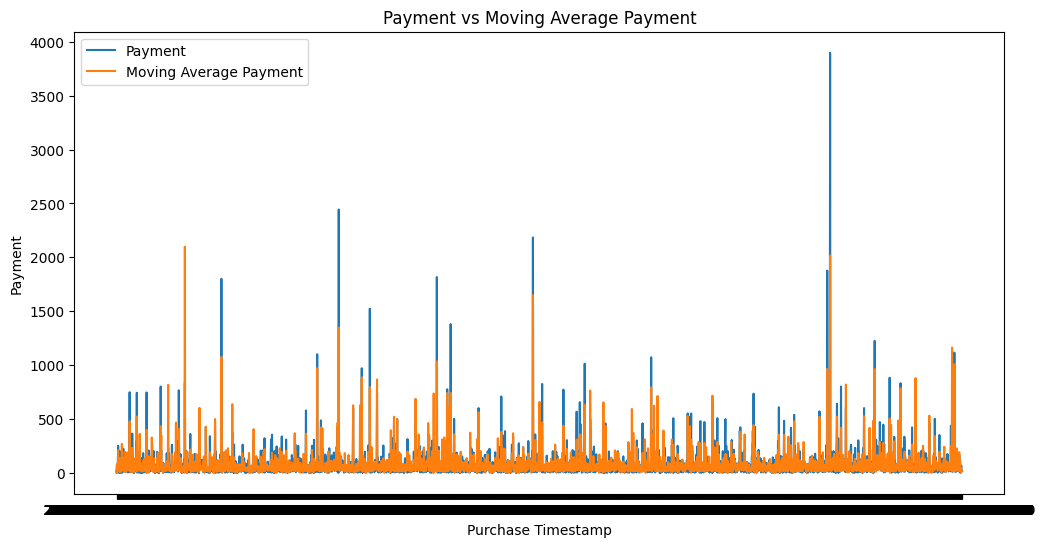

In [96]:
plt.figure(figsize=(12, 6))
plt.plot(df_moving_avg_payment_diff['purchase_timestamp'], df_moving_avg_payment_diff['payment'], label='Payment')
plt.plot(df_moving_avg_payment_diff['purchase_timestamp'], df_moving_avg_payment_diff['moving_avg_payment'], label='Moving Average Payment')
plt.xlabel('Purchase Timestamp')
plt.ylabel('Payment')
plt.title('Payment vs Moving Average Payment')
plt.legend()
plt.show()

Since the dataset is too large, we will only use the first 100 rows for analysis.

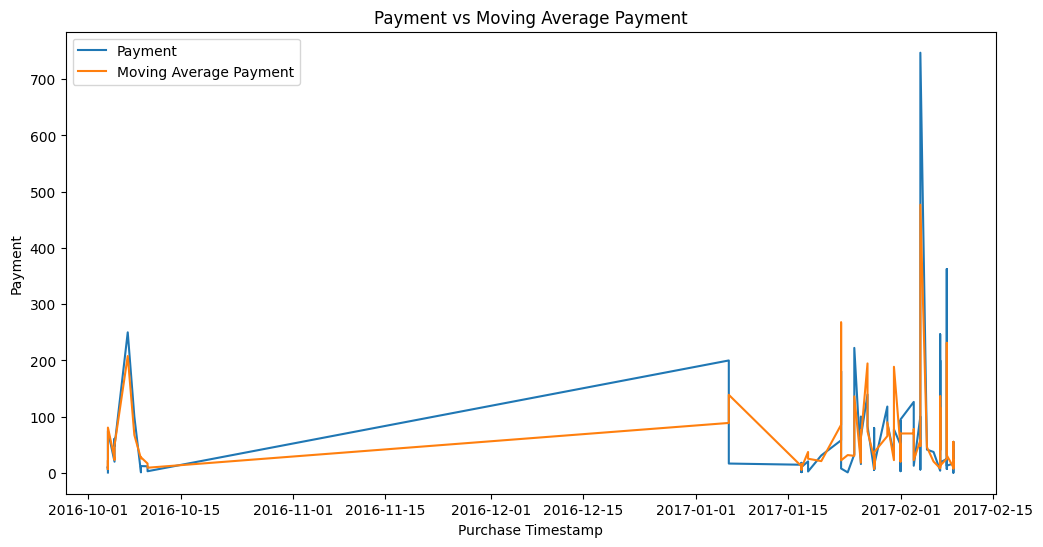

In [99]:
df_moving_avg_payment_diff['purchase_timestamp'] = pd.to_datetime(df_moving_avg_payment_diff['purchase_timestamp'])

plt.figure(figsize=(12, 6))
plt.plot(df_moving_avg_payment_diff['purchase_timestamp'].head(100).dt.date, df_moving_avg_payment_diff['payment'].head(100), label='Payment')
plt.plot(df_moving_avg_payment_diff['purchase_timestamp'].head(100).dt.date, df_moving_avg_payment_diff['moving_avg_payment'].head(100), label='Moving Average Payment')
plt.xlabel('Purchase Timestamp')
plt.ylabel('Payment')
plt.title('Payment vs Moving Average Payment')
plt.legend()
plt.show()

The moving average payment is flactuating over time like a stock price.

---

### Calculating the cumulative sales per month for each year

Creating a cummulative sales column. I used subquery to create a running total of sales. I extracted year and month from the order purchase timestamp and grouped the data by year and month. I then ordered the data by year and month. I then used the sum function to calculate the running total of sales. I then rounded the running total to 2 decimal places. I stored the result in a new column called running_sales.

In [126]:
query = """select years, months, sales, round(sum(sales) over(order by years, months), 2) as running_sales
from (select year(orders.order_purchase_timestamp) as years,
month(orders.order_purchase_timestamp) as months,
round(sum(payments.payment_value), 2) as sales from orders 
join payments
on orders.order_id = payments.order_id
group by years, months
order by years, months) as a"""

db = mysql.connector.connect(
    host="localhost",
    user="root",
    password="parshvpatel@0910",
    database="target"
)

cursor = db.cursor()
cursor.execute(query)
result = cursor.fetchall()
for row in result[:10]:
    print(row[0]," ", row[1], " ", row[2], " ", row[3])

2016   9   252.24   252.24
2016   10   59090.48   59342.72
2016   12   19.62   59362.34
2017   1   138488.04   197850.38
2017   2   291908.01   489758.39
2017   3   449863.6   939621.99
2017   4   417788.03   1357410.02
2017   5   592918.82   1950328.84
2017   6   511276.38   2461605.22
2017   7   592382.92   3053988.14


Creating a dataframe to store the sales data

In [127]:
df = pd.DataFrame(result, columns=["years", "months", "sales", "running_sales"])
df.head()

,years,months,sales,running_sales
0,2016,9,252.24,252.24
1,2016,10,59090.48,59342.72
2,2016,12,19.62,59362.34
3,2017,1,138488.04,197850.38
4,2017,2,291908.01,489758.39


In [128]:
df.tail()

,years,months,sales,running_sales
20,2018,6,1023880.50,13914876.84
21,2018,7,1066540.75,14981417.59
22,2018,8,1022425.32,16003842.91
23,2018,9,4439.54,16008282.45
24,2018,10,589.67,16008872.12


The data starts from the 9th month of 2016 and ends at the 10th month of 2018. 

Visualizing the data to understand the sales trends. I plotted the running sales to see how the sales have changed over time.

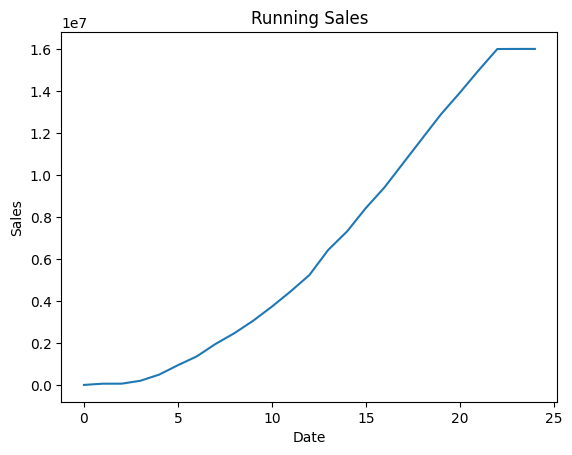

In [129]:
df["running_sales"].plot() 
plt.title("Running Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()


Adding dates to the x axis to see the running sales over time

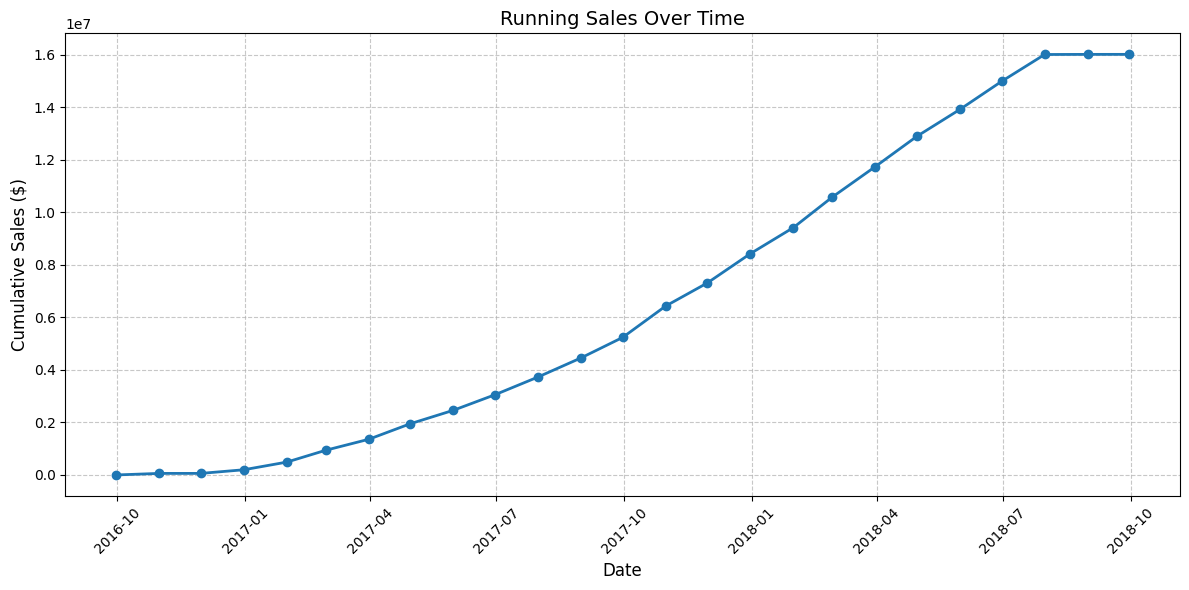

In [132]:
dates = pd.date_range(start='2016-09', end='2018-10', freq='M')
sales = df["running_sales"]
df = pd.DataFrame({'date': dates, 'running_sales': sales})

plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['running_sales'], marker='o', linestyle='-', linewidth=2)

plt.title('Running Sales Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

The graph shows a steady increase in cumulative sales over time with slower growth initially for 3 months, followed by a steady growth for 13-14 months, and flattening out in the last 2 months.

---
### Calculating the year over year growth rate of total sales

I used the similar subquery to calculate the year-over-year growth rate of sales. First, I created a common table expression named a that calculates the total sales for each year by joining the "orders" and "payments" tables on the "order_id" column and grouping the results by year. Then, I used the "lag" function to calculate the sales for the previous year and used it to calculate the year-over-year growth rate using the formula (current_sales - previous_sales) / previous_sales * 100.

In [124]:
query = """with a as (select year(orders.order_purchase_timestamp) as years,
round(sum(payments.payment_value), 2) as sales from orders 
join payments
on orders.order_id = payments.order_id
group by years
order by years) select years, sales, round((sales - lag(sales) over(order by years)) / lag(sales) over(order by years) * 100, 2) as yoy_growth from a"""

cursor.execute(query)
result = cursor.fetchall()
df= pd.DataFrame(result, columns=["years", "sales", "yoy_growth"])
df

,years,sales,yoy_growth
0,2016,59362.34,NaN
1,2017,7249746.73,12112.7
2,2018,8699763.05,20.0


This makes sense that the year-over-year growth rate of sales is positive from year 2016 to 2017 is 12112.7% because the sales in 2016 only includes from 2016-09 with a very small amount of sales as I visualized in the previous question. However, the sales in 2017 includes the entire year of 2017 with a much larger amount of sales. There is 20% increase in sales from 2017 to 2018. This is also because 2018 only includes upto the 10th month with sales flattening for the 9th and 10th month.

---
### Calculating the rentention rate of customers with the percentage of customer who make another purchase withing 6 months of their first purchase

First, I created a subquery with common table expression a where I selected the first order of each customer. Then I created another subquery with common table expression b where I selected the orders of each customer made atleast in the interval of next 6 months from their first order. Then I calculated the retention rate by dividing the number of customers who made a purchase in the last 6 months by the total number of customers and multiplying by 100.

In [146]:
query = """with a as (select customers.customer_id,
min(orders.order_purchase_timestamp) as first_order
from customers join orders
on customers.customer_id = orders.customer_id
group by customers.customer_id),

b as (select a.customer_id, count(distinct orders.order_purchase_timestamp) as next_order
from a join orders
on orders.customer_id = a.customer_id
and orders.order_purchase_timestamp >= a.first_order
and orders.order_purchase_timestamp < date_add(a.first_order, interval 6 month)
group by a.customer_id)

select 100 * sum(case when b.next_order > 1 then 1 else 0 end) / count(*) as retention_rate
from b
"""

cursor.execute(query)
result = cursor.fetchall()
print(result[0][0])

0.0000


The result is 0% which means the retention rate is 0% and there are no customers who have made a repeat purchase in the last 6 months. Either they bought multiple items in a single purchase or they have not made a repeat purchase in the last 6 months.

---
### Identifying the top 3 customers who spent the most money in each year

First, I selected years, customer id, sum of payment value, and dense rank of customers partitioned by years and ordered by sum of payment value in descending order from orders and payments tables joined on order id. Then, I grouped by years and customer id and ordered by years and dense rank. Then, I limited the result to 3 customers per year.

In [163]:
query = """select years, customer_id, payment, customer_rank
from
(select year(o.order_purchase_timestamp) as years, 
o.customer_id, 
round(sum(p.payment_value), 2) as payment, 
dense_rank() over(partition by year(o.order_purchase_timestamp)
order by sum(p.payment_value) desc) as customer_rank
from orders o
join payments p 
on o.order_id = p.order_id
group by year(o.order_purchase_timestamp), 
o.customer_id
order by years, customer_rank) as top_customers
where customer_rank <= 3"""

cursor.execute(query)
result = cursor.fetchall()
for row in result:
    print(row)

(2016, 'a9dc96b027d1252bbac0a9b72d837fc6', 1423.55, 1)
(2016, '1d34ed25963d5aae4cf3d7f3a4cda173', 1400.74, 2)
(2016, '4a06381959b6670756de02e07b83815f', 1227.78, 3)
(2017, '1617b1357756262bfa56ab541c47bc16', 13664.08, 1)
(2017, 'c6e2731c5b391845f6800c97401a43a9', 6929.31, 2)
(2017, '3fd6777bbce08a352fddd04e4a7cc8f6', 6726.66, 3)
(2018, 'ec5b2ba62e574342386871631fafd3fc', 7274.88, 1)
(2018, 'f48d464a0baaea338cb25f816991ab1f', 6922.21, 2)
(2018, 'e0a2412720e9ea4f26c1ac985f6a7358', 4809.44, 3)


Creating a dataframe from the the results of the query and visualizing the the payments made by this top customers

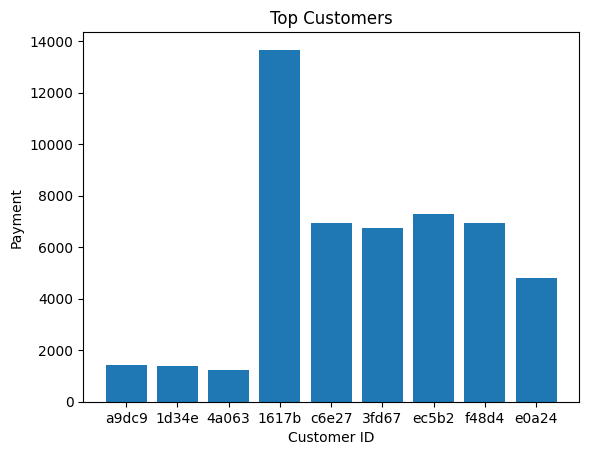

In [170]:
df_top_customers = pd.DataFrame(result, columns=["years", "customer_id", "payment", "customer_rank"])

df_top_customers["customer_id"] = df_top_customers["customer_id"].str[:5]

plt.bar(df_top_customers["customer_id"], df_top_customers["payment"])
plt.xlabel("Customer ID")
plt.ylabel("Payment")
plt.title("Top Customers")
plt.show()

As we can see, the customer with id starting "1617b" has made the highest payment in all 3 years and the customer was from 2017 year.

Creating a more detailed graph using Seaborn library to get hue for the years.

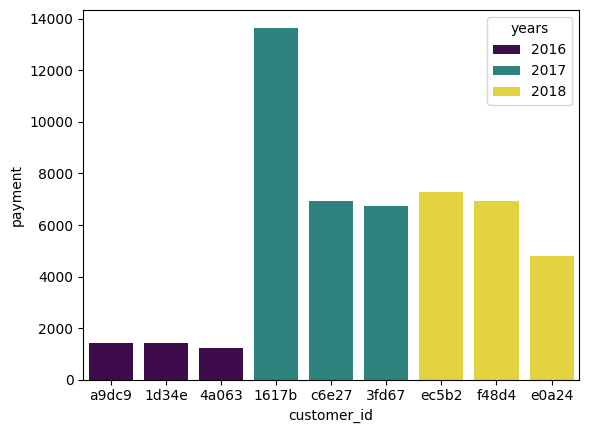

In [172]:
sns.barplot(x="customer_id", y="payment", data=df_top_customers, hue="years", palette="viridis")
plt.show()

Both 2017 and 2018 have similar payment amounts from the top customers except for the customer "1617b" who made the highest payment in 2017 of $13664

---

## Author

- [Parshv Patel](https://www.linkedin.com/in/parshv-patel-65a90326b/)